In [4]:
!pip install seaborn

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [9]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [12]:
df=df.replace({"Male":1, "Female":0})
print(df.info())
print('\n')
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB
None


       CustomerID      Gender         Age  Annual Income (k$)  \
count  200.000000  200.000000  200.000000          200.000000   
mean   100.500000    0.440000   38.850000           60.560000   
std     57.879185    0.497633   13.969007           26.264721   
min      1.000000    0.000000   18.000000           15.000000   
25%     50.750000    0.000000   28.750000           41.500000   
50%    100.500000    0.000000   36.000000           61.500000   
75%    150.250000    1.000000   49.0000

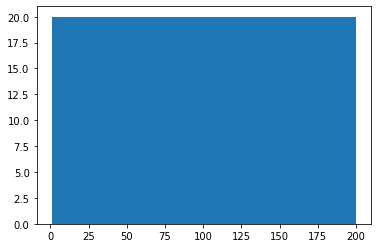

histogram of CustomerID




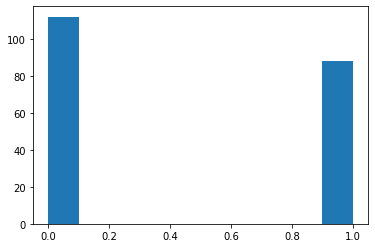

histogram of Gender




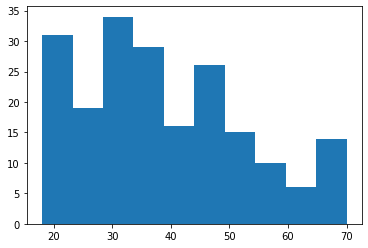

histogram of Age




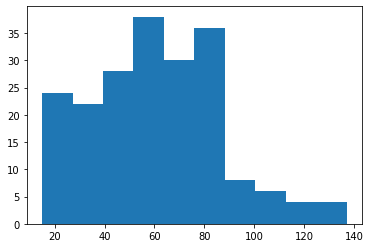

histogram of Annual Income (k$)




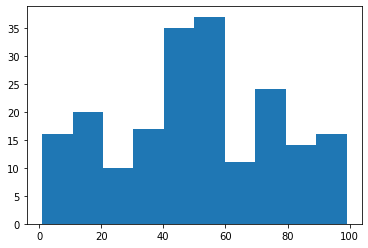

histogram of Spending Score (1-100)




In [13]:
for i in df[['CustomerID', 'Gender', 'Age', 'Annual Income (k$)','Spending Score (1-100)']]:
    plt.hist(df[i])
    plt.show()
    print("histogram of {}".format(i))
    print('\n')

In [14]:
df=df.drop(["CustomerID"],axis=1)
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


C:\Users\taran\anaconda3\envs\idp\lib\site-packages\sklearn\cluster\_kmeans.py:882: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  f"KMeans is known to have a memory leak on Windows "




Num of Cluster: 1
[[ 0.44 38.85 60.56 50.2 ]] 308862.06000000006


Num of Cluster: 2
[[ 0.43478261 46.16521739 59.36521739 32.88695652]
 [ 0.44705882 28.95294118 62.17647059 73.62352941]] 212889.44245524294


Num of Cluster: 3
[[ 0.40650407 40.32520325 44.15447154 49.82926829]
 [ 0.46153846 32.69230769 86.53846154 82.12820513]
 [ 0.52631579 40.39473684 87.         18.63157895]] 143391.59236035674


Num of Cluster: 4
[[ 0.46153846 32.69230769 86.53846154 82.12820513]
 [ 0.51351351 40.32432432 87.43243243 18.18918919]
 [ 0.38541667 44.875      48.9375     42.55208333]
 [ 0.5        24.82142857 28.71428571 74.25      ]] 104422.83498539754


Num of Cluster: 5
[[ 0.42307692 43.28205128 55.02564103 49.69230769]
 [ 0.46153846 32.69230769 86.53846154 82.12820513]
 [ 0.39130435 25.52173913 26.30434783 78.56521739]
 [ 0.51351351 40.32432432 87.43243243 18.18918919]
 [ 0.39130435 45.2173913  26.30434783 20.91304348]] 75421.38291301334


Num of Cluster: 6
[[ 0.46153846 32.69230769 86.53846154 82

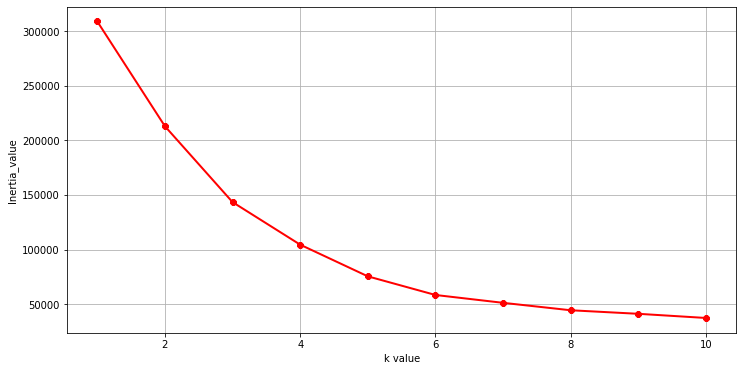

In [16]:
x=np.asanyarray(df)
wcss =[]
num_cluster=10
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, init = "k-means++")
    kmeans.fit(x)
    print('\n')
    print("Num of Cluster: {}".format(k))
    print(kmeans.cluster_centers_, kmeans.inertia_)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(12,6))
plt.grid()
plt.plot(range(1,11) , wcss , linewidth=2, color="red" , marker="8")
plt.xlabel("k value")
plt.ylabel("Inertia_value")
plt.show()

In [17]:
## Best value of K is 6
x=np.asanyarray(df)
kmeans=KMeans(n_clusters=6, init = "k-means++")
kmeans.fit(x)
pred_cluster_x=kmeans.fit_predict(x)
print("Also lets add the cluster number in DataFrame")
df['Cluster']=pd.DataFrame(data=pred_cluster_x,columns=['Cluster'])
df.head()

Also lets add the cluster number in DataFrame


,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,0
1,1,21,15,81,5
2,0,20,16,6,0
3,0,23,16,77,5
4,0,31,17,40,0


In [19]:
for i in range(6):
    filt_df=df[df['Cluster']==i]
    print("Statistical Attributes of Cluster:{}".format(i))
    print(filt_df.describe())
    print('\n')

Statistical Attributes of Cluster:0
          Gender        Age  Annual Income (k$)  Spending Score (1-100)  \
count  21.000000  21.000000           21.000000               21.000000   
mean    0.380952  44.142857           25.142857               19.523810   
std     0.497613  13.089254            7.226934               12.769569   
min     0.000000  19.000000           15.000000                3.000000   
25%     0.000000  35.000000           19.000000                6.000000   
50%     0.000000  45.000000           24.000000               15.000000   
75%     1.000000  53.000000           30.000000               31.000000   
max     1.000000  67.000000           39.000000               40.000000   

       Cluster  
count     21.0  
mean       0.0  
std        0.0  
min        0.0  
25%        0.0  
50%        0.0  
75%        0.0  
max        0.0  


Statistical Attributes of Cluster:1
          Gender        Age  Annual Income (k$)  Spending Score (1-100)  \
count  38.000000  38.0